# Platforms and Matchmakers

> Computational Analysis of Social Complexity
>
> Fall 2026, Spencer Lyon

**Prerequisites**

- Graph theory (weeks 3-4)
- Game theory basics (week 8)

**Outcomes**

- Define multisided platforms and distinguish same-side and cross-side network effects
- Explain fulfilled-expectations equilibrium and critical mass
- Compute and classify equilibria of a network-effects demand model in Python
- Connect platform pricing puzzles to cross-side externalities

**References**

- [Easley and Kleinberg, Chapter 17: Network Effects (required)](https://www.cs.cornell.edu/home/kleinber/networks-book/networks-book.pdf)
- [Katz and Shapiro (1985), *Network Externalities, Competition, and Compatibility*](https://idv.sinica.edu.tw/kongpin/teaching/io/KatzShapiro1.pdf)
- *Matchmakers* (Evans and Schmalensee, 2016), Chapters 1-3 (optional extra reading)

## Dinner, a Card, and a 7% Fee

- In 1950, Diners Club launched what became the first credit card
- The pitch linked two groups that needed one another:
  - Diners wanted to eat without carrying cash
  - Restaurants wanted diners who would spend
- Diners received the card for roughly free
- Participating restaurants paid Diners Club about **7%** of each bill
- That sounds backward at first: why charge the businesses that make the service possible?

### Three Pricing Puzzles

- Why is your credit card free—or even pays rewards—while merchants pay roughly 2-3%?
- Why is OpenTable free for diners while restaurants pay?
- Why would a nightclub offer a **Ladies Night** discount to one group?
- These are not three unrelated marketing tricks
- By the end of this unit, we will see that they are versions of the **same formula**

### Our Four-Lecture Map

- Today: platforms, network effects, and **critical mass**
- L11.02: **tipping**, the **chicken-and-egg problem**, and competition between platforms
- L12.01: **multihoming** and why **price structure** matters separately from **price level**
- L12.02: **stable matching** and the pairs that can unravel an assignment—a **blocking pair**
- Our common question: how does an intermediary get the right participants together?

## What Is a Platform?

- A **pipe** creates value by transforming inputs into outputs
  - A bakery turns flour, labor, and ovens into bread
  - Value moves mostly along one production chain
- A **platform** creates value by connecting two or more groups
  - The platform is a **matchmaker**
  - Each group joins partly because the other group is there
- The distinction is about the source of value—not whether the business owns servers or has an app

### Matchmakers in the Wild

- Read each row from left to right: who needs whom?

| Platform | Side A | Side B | What the platform coordinates |
|---|---|---|---|
| Credit cards | Cardholders | Merchants | Payment acceptance |
| OpenTable | Diners | Restaurants | Reservations and empty tables |
| Ride-share | Riders | Drivers | Trips in a place and time |
| Ad-supported media | Readers | Advertisers | Attention and messages |
| App stores | Users | Developers | Software discovery and distribution |

- A platform can operate pipes too, but matchmaking is the economic engine

### Exercise 1: Pipe or Platform?

- Classify three more businesses: a grocery store, a dating app, and a video-game console
- For each one:
  1. Is its main value created like a pipe, a platform, or both?
  2. If it is a platform, name the sides
  3. What does one side gain when the other side grows?
- Be ready to defend one classification that could reasonably go either way

## When the Network Is Part of the Product

- Recall homophily and tie strength from weeks 3-4
- There, network **structure** shaped individual behavior
- Now the **size** of the network is part of the product itself
- A **network effect** occurs when one participant changes another participant's value from joining
- We need to ask two questions:
  1. Are the participants on the same side or opposite sides?
  2. Does another participant create a positive or negative effect?

### Same-Side Network Effects

- **Same-side network effects** run among participants in the same group
- They can be positive:
  - More gamers make a multiplayer game more fun
  - More colleagues on a messaging service make it more useful
- They can be negative:
  - More riders requesting trips at once create congestion and longer waits
  - More drivers compete for the same set of fares
- More is not automatically better—even on a network

### Cross-Side Network Effects

- **Cross-side network effects** run from one group to another
- More ride-share drivers usually improve the service for riders
- More riders create more earning opportunities for drivers
- More merchants make a credit card useful to cardholders
- More cardholders make acceptance valuable to merchants
- The feedback can reinforce itself: side A attracts side B, which attracts still more of side A

### Exercise 2: Trace the Effects

- Consider a ride-share platform
- Draw one arrow for each effect and label it positive or negative:
  - Riders $\rightarrow$ riders
  - Drivers $\rightarrow$ drivers
  - Riders $\rightarrow$ drivers
  - Drivers $\rightarrow$ riders
- Which effect changes sign when a city moves from a quiet afternoon to bar-closing time?
- Which effects can the platform influence with prices?

## Expectations Can Create Demand

- Suppose a new network product launches today
- Would you join if you expected nobody else to join?
- Would you join if you expected almost everyone else to join?
- The product and price did not change—only your expectation did
- Katz and Shapiro call this a **fulfilled-expectations** problem:
  - Expectations determine adoption
  - Adoption then confirms or contradicts those expectations

### Consumers First, Equations Second

- Consumers differ in taste for the product
- Index consumers by $x$, uniformly distributed on $[0,1]$
- Let $n^e$ be the network size consumers **expect**
- Let $f(n^e)$ be the value created by a network of that expected size
- A consumer with taste $x$ is willing to pay

$$x f(n^e).$$

- High-$x$ consumers value the product more; everyone values a stronger network more

### From a Joining Rule to Demand

- At price $p$, consumer $x$ joins when

$$x f(n^e) \ge p.$$

- The marginal consumer has $x^*=p/f(n^e)$
- Because $x$ is uniform on $[0,1]$, the share above $x^*$ is realized adoption

$$n=g(n^e;p)=\operatorname{clamp}\left(1-\frac{p}{f(n^e)},0,1\right).$$

- Expected adoption goes in; realized adoption comes out

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(6318)
plt.rcParams["lines.linewidth"] = 3
plt.rcParams["figure.figsize"] = (7.6, 4.5)

In [2]:
# Network value is positive even before the network grows
def network_value(n, a=0.1, b=1.0):
    return a + b * n


def realized_adoption(n_expected, p, a=0.1, b=1.0):
    value = network_value(n_expected, a=a, b=b)
    return np.clip(1 - p / value, 0.0, 1.0)


a, b, p = 0.1, 1.0, 0.2


def g(n_expected):
    return realized_adoption(n_expected, p, a=a, b=b)

### Expectations Versus Outcomes

- The curved line asks: if consumers expect $n^e$, how many actually join?
- The 45-degree line asks: where does realized adoption equal expected adoption?
- Before looking at the plot, make a prediction:
  - How many intersections will there be?
  - Will pessimistic and optimistic beliefs lead to the same outcome?

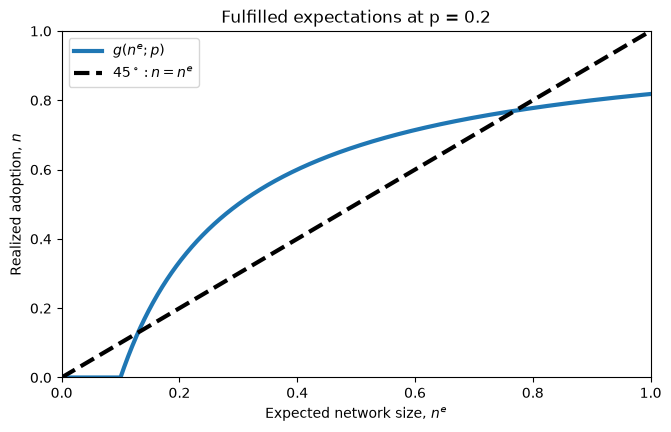

In [3]:
n_grid = np.linspace(0.0, 1.0, 1001)

fig, ax = plt.subplots()
ax.plot(n_grid, g(n_grid), label=r"$g(n^e; p)$")
ax.plot(n_grid, n_grid, label=r"$45^\circ: n=n^e$", linestyle="--", color="black")
ax.set_xlabel(r"Expected network size, $n^e$")
ax.set_ylabel("Realized adoption, $n$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title(f"Fulfilled expectations at p = {p}")
ax.legend(loc="best")
plt.show()

## Fulfilled-Expectations Equilibrium

- An equilibrium occurs when expectations are fulfilled
- In symbols, expected size and realized size agree:

$$n^*=g(n^*;p).$$

- This looks like the Nash equilibrium logic from week 8
  - Each consumer responds optimally to a belief about everyone else
  - The aggregate behavior must be consistent with that belief
- Here we are looking for **fixed points** rather than best-response intersections

In [4]:
# Bisection needs only a continuous function and a sign-changing interval
def bisect_zero(h, left, right, tol=1e-10, maxiter=200):
    f_left, f_right = h(left), h(right)
    if abs(f_left) < tol:
        return left
    if abs(f_right) < tol:
        return right
    if f_left * f_right > 0:
        raise ValueError("The interval does not bracket a root")

    for _ in range(maxiter):
        middle = (left + right) / 2
        f_middle = h(middle)
        if abs(f_middle) < tol or right - left < tol:
            return middle

        if f_left * f_middle < 0:
            right = middle
        else:
            left, f_left = middle, f_middle
    return (left + right) / 2

In [5]:
# Scan [0,1] for brackets, then refine every crossing with bisection
def fixed_points(g, grid_size=4000, tol=1e-8):
    xs = np.linspace(0.0, 1.0, grid_size + 1)
    gaps = g(xs) - xs
    roots = []

    for i in range(len(xs)):
        if abs(gaps[i]) < tol:
            roots.append(xs[i])
    for i in range(len(xs) - 1):
        if gaps[i] * gaps[i + 1] < 0:
            h = lambda n: g(n) - n
            roots.append(bisect_zero(h, xs[i], xs[i + 1]))

    roots.sort()
    unique_roots = []
    for root in roots:
        if not unique_roots or abs(root - unique_roots[-1]) > 1e-5:
            unique_roots.append(root)
    return unique_roots

In [6]:
equilibria = fixed_points(g)
n_zero, n_L, n_H = equilibria

{
    "equilibria": [round(e, 4) for e in equilibria],
    "critical_candidate": round(n_L, 4),
    "high_adoption": round(n_H, 4),
}

{'equilibria': [np.float64(0.0), np.float64(0.1298), np.float64(0.7702)],
 'critical_candidate': np.float64(0.1298),
 'high_adoption': np.float64(0.7702)}

### Three Self-Consistent Stories

- $n=0$: consumers expect no network, so nobody joins
- $n=n_L$: consumers expect a modest network, and exactly that share joins
- $n=n_H$: consumers expect a large network, and a large share joins
- All three satisfy the equilibrium equation
- But equilibrium does not automatically mean **stable**
- Which stories survive a small mistake in expectations?

### Stability: Push the System, Then Watch

- Imagine expected adoption is nudged slightly away from an equilibrium
- If the next realized adoption moves back, the equilibrium is **stable**
- If it moves farther away, the equilibrium is **unstable**
- Locally, the slope of the response map gives the test:

$$|g'(n^*;p)|<1 \Rightarrow \text{stable}, \qquad |g'(n^*;p)|>1 \Rightarrow \text{unstable}.$$

- Intuition first: a stable response dampens a small error; an unstable response amplifies it

In [7]:
def response_slope(n, p, a=0.1, b=1.0):
    raw_adoption = 1 - p / (a + b * n)
    if raw_adoption <= 0 or raw_adoption >= 1:
        return 0.0
    return p * b / (a + b * n) ** 2


equilibrium_report = [
    {
        "n": round(n, 4),
        "slope": round(response_slope(n, p, a=a, b=b), 3),
        "classification": "stable" if abs(response_slope(n, p, a=a, b=b)) < 1 else "unstable",
    }
    for n in equilibria
]
equilibrium_report

[{'n': np.float64(0.0), 'slope': 0.0, 'classification': 'stable'},
 {'n': np.float64(0.1298),
  'slope': np.float64(3.786),
  'classification': 'unstable'},
 {'n': np.float64(0.7702),
  'slope': np.float64(0.264),
  'classification': 'stable'}]

## Let Expectations Update

- Give consumers yesterday's adoption as today's expectation
- The update rule is deliberately simple:

$$n_{t+1}=g(n_t;p).$$

- Recall emergence from the ABMs in weeks 6-7
- A simple individual joining rule can create sharply different aggregate paths
- We will start on both sides of $n_L$ and let the feedback run

In [8]:
def adoption_path(n0, g, periods=25):
    path = np.zeros(periods + 1)
    path[0] = n0
    for t in range(periods):
        path[t + 1] = g(path[t])
    return path


starting_points = [0.05, 0.12, 0.14, 0.50, 0.95]
paths = np.column_stack([adoption_path(n0, g) for n0 in starting_points])

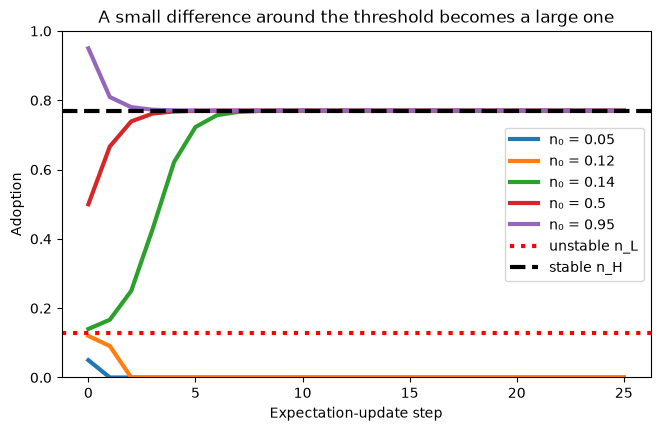

In [9]:
fig, ax = plt.subplots()
for i, n0 in enumerate(starting_points):
    ax.plot(range(26), paths[:, i], label=f"n₀ = {n0}")
ax.set_xlabel("Expectation-update step")
ax.set_ylabel("Adoption")
ax.set_ylim(0, 1)
ax.set_title("A small difference around the threshold becomes a large one")
ax.axhline(n_L, color="red", linestyle=":", label="unstable n_L")
ax.axhline(n_H, color="black", linestyle="--", label="stable n_H")
ax.legend(loc="best")
plt.show()

## Reveal: The Middle Equilibrium Is a Threshold

- The middle equilibrium $n_L$ is **unstable**
- Start just below it and adoption spirals toward zero
- Start just above it and adoption snowballs toward $n_H$
- We call this threshold **critical mass**
- Crossing critical mass can lead to **tipping**: self-reinforcing movement toward high adoption
- This is why "build it and they will come" can fail
  - A good product below critical mass can still die
  - Expectations and initial participation are economic inputs, not background details

### The Chicken-and-Egg Problem

- Diners will not carry a card that few restaurants accept
- Restaurants will not accept a card that few diners carry
- Riders want drivers before opening the app; drivers want riders before going online
- This is the platform **chicken-and-egg problem**
- Diners Club's answer was to make the card roughly free for cardholders
- The giveaway was not generosity—it helped move one side toward critical mass

### Price Structure Is Not Price Level

- A platform chooses a price for each side
- **Price level** asks how much the platform collects in total
- **Price structure** asks which side pays how much
- Moving one dollar of the fee from diners to restaurants can change participation even if total fees stay fixed
- Why? Each side creates a cross-side externality for the other
- **Multihoming**—using more than one platform—will further change how strongly each side can be charged
- We will derive that pricing logic in L12.01

## Comparative Statics: Lower the Price

- Our model gives a direct prediction
- Lower price means more consumers join at any expected network size
- Graphically, the realized-adoption curve shifts upward
- The unstable intersection moves left: **critical mass shrinks**
- At a sufficiently low price, even a tiny initial network begins to grow
- Let us compute the threshold across prices rather than trust the picture

In [10]:
def critical_mass(price, a=0.1, b=1.0):
    def response(n):
        return realized_adoption(n, price, a=a, b=b)

    roots = fixed_points(response)
    unstable = [
        n for n in roots
        if response_slope(n, price, a=a, b=b) > 1 + 1e-6
    ]
    return min(unstable) if unstable else 0.0


prices = np.linspace(0.10, 0.30, 81)
thresholds = [critical_mass(price, a=a, b=b) for price in prices]

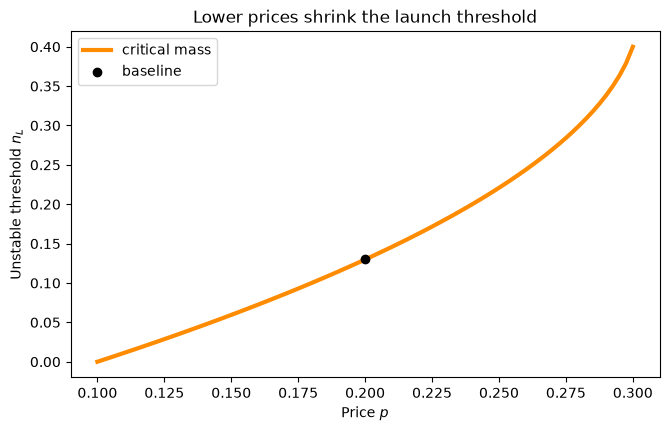

In [11]:
fig, ax = plt.subplots()
ax.plot(prices, thresholds, label="critical mass", color="darkorange")
ax.set_xlabel("Price $p$")
ax.set_ylabel(r"Unstable threshold $n_L$")
ax.set_title("Lower prices shrink the launch threshold")
ax.scatter([p], [n_L], label="baseline", color="black", s=36, zorder=5)
ax.legend(loc="best")
plt.show()

### Exercise 3: Classify Four Platforms

- For each platform below, identify one same-side effect and one cross-side effect
- Label every effect positive or negative:
  1. Credit cards: cardholders and merchants
  2. Ride-share: riders and drivers
  3. Multiplayer gaming: players and game developers
  4. Ad-supported social media: users and advertisers
- Your ride-share answer must include at least one **negative same-side effect**
- Which platform has the strongest case for subsidizing one side? Explain

### Exercise 4: A Different Network-Value Function

- Replace the linear network value with $f(n)=\sqrt{n}$
- Set $p=0.1$ and reuse `fixed_points`
- Report:
  1. The number of fulfilled-expectations equilibria on $[0,1]$
  2. The adoption level of each equilibrium
  3. Which equilibrium is the critical mass
- Classify stability by iterating from just above and just below each interior equilibrium

In [12]:
def f_sqrt(n):
    return np.sqrt(n)


p_sqrt = 0.1

# TODO: define realized adoption g_sqrt(n), remembering to clip to [0,1]
# TODO: call fixed_points(g_sqrt) and report the equilibria
# TODO: iterate from values just above and below the interior equilibria

### Exercise 5: Subsidize Early Adopters

- Suppose the platform temporarily sets $p<0$: early adopters are paid to join
- Before computing, predict what happens to critical mass
- Then modify the baseline model and compare $p=-0.05$, $p=0$, and $p=0.05$
- Does our clamped demand model predict partial adoption or immediate full adoption under a subsidy?
- What real-world friction is missing if the prediction seems too strong?
- Connect your answer to why platforms offer referral bonuses, free trials, or rewards

In [13]:
subsidy_prices = [-0.05, 0.0, 0.05]

# TODO: create one realized-adoption curve for each price
# TODO: plot the curves against the 45-degree line
# TODO: explain what happens to the chicken-and-egg problem

## Takeaways

- Platforms are matchmakers: they create value by connecting distinct groups
- **Same-side network effects** operate within a group; **cross-side network effects** operate across groups
- Fulfilled-expectations equilibria require expected adoption to equal realized adoption
- Multiple equilibria make history and expectations matter
- The unstable middle equilibrium is **critical mass**
- Below critical mass, adoption can collapse; above it, feedback can produce **tipping**
- Subsidizing one side can be a rational response to the **chicken-and-egg problem**

## Next Time

- We have identified the threshold, but not how a real platform crosses it
- Next time: how do platforms actually ignite?
- We'll simulate the race to critical mass—and see the winner isn't always the better platform